<a href="https://colab.research.google.com/github/AleximperV/ThucHanhDeepLearning/blob/main/Tuan_2/ANNLyThuyetPhan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
# Load dataset Fashion MNIST từ TensorFlow/Keras
fashion_mnist = keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [4]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Số lớp:", len(class_names))

Số lớp: 10


In [5]:
# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min pixel:", X_train.min())
print("Max pixel:", X_train.max())
print("Số class:", len(np.unique(y_train)))
print("Các class:", np.unique(y_train))

Min pixel: 0.0
Max pixel: 1.0
Số class: 10
Các class: [0 1 2 3 4 5 6 7 8 9]


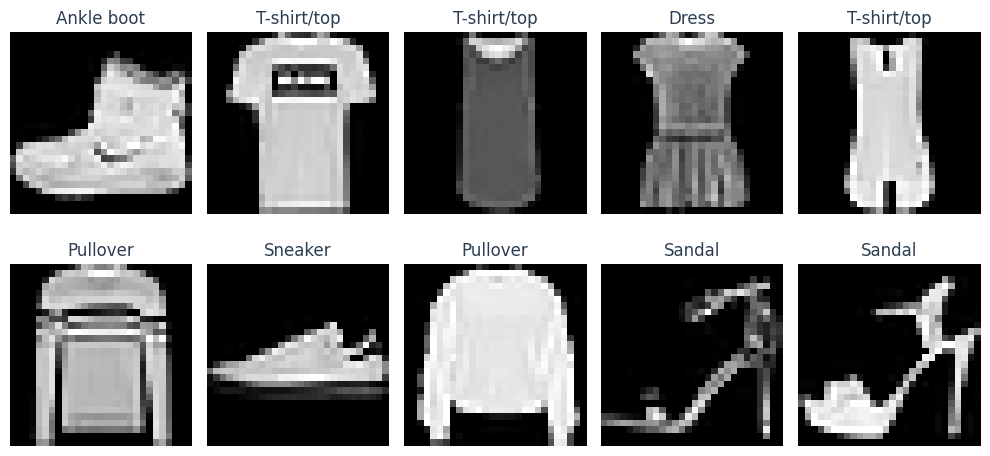

In [6]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8060 - loss: 0.5555 - val_accuracy: 0.8499 - val_loss: 0.4306
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8581 - loss: 0.4045 - val_accuracy: 0.8505 - val_loss: 0.4106
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8729 - loss: 0.3593 - val_accuracy: 0.8694 - val_loss: 0.3673
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8802 - loss: 0.3307 - val_accuracy: 0.8743 - val_loss: 0.3497
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8873 - loss: 0.3120 - val_accuracy: 0.8789 - val_loss: 0.3401
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8927 - loss: 0.2956 - val_accuracy: 0.8836 - val_loss: 0.3227
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8988 - loss: 0.2791 - val_accuracy: 0.8839 - val_loss: 0.3279
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9039 - loss: 0.2661 - val_accuracy: 0

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.3469280004501343
Test accuracy: 0.8855000138282776


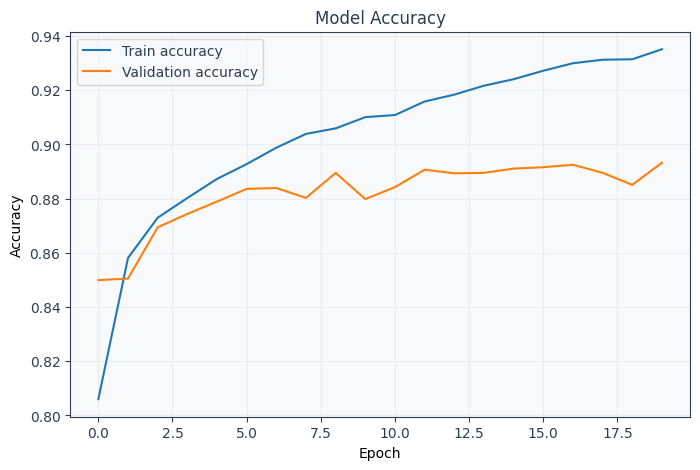

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

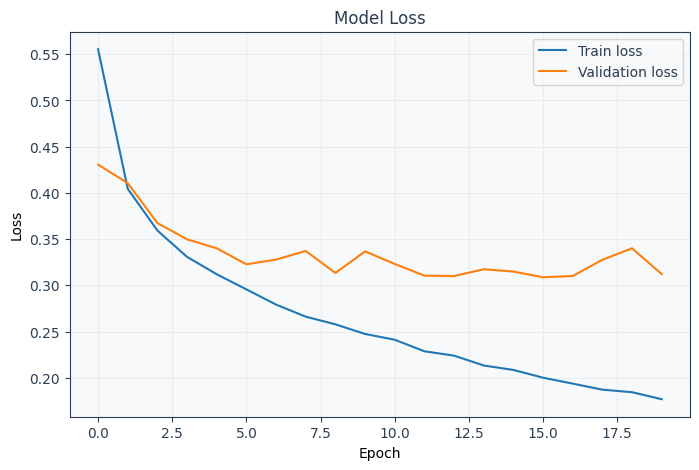

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Nhãn dự đoán: 9 - Ankle boot
Nhãn thực tế: 9 - Ankle boot


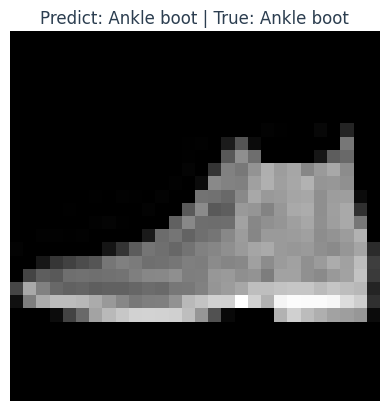

In [12]:
predictions = model.predict(X_test)

index = 0

predicted_label = np.argmax(predictions[index])
true_label = y_test[index]

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thực tế:", true_label, "-", class_names[true_label])

plt.imshow(X_test[index], cmap="gray")
plt.title(f"Predict: {class_names[predicted_label]} | True: {class_names[true_label]}")
plt.axis("off")
plt.show()

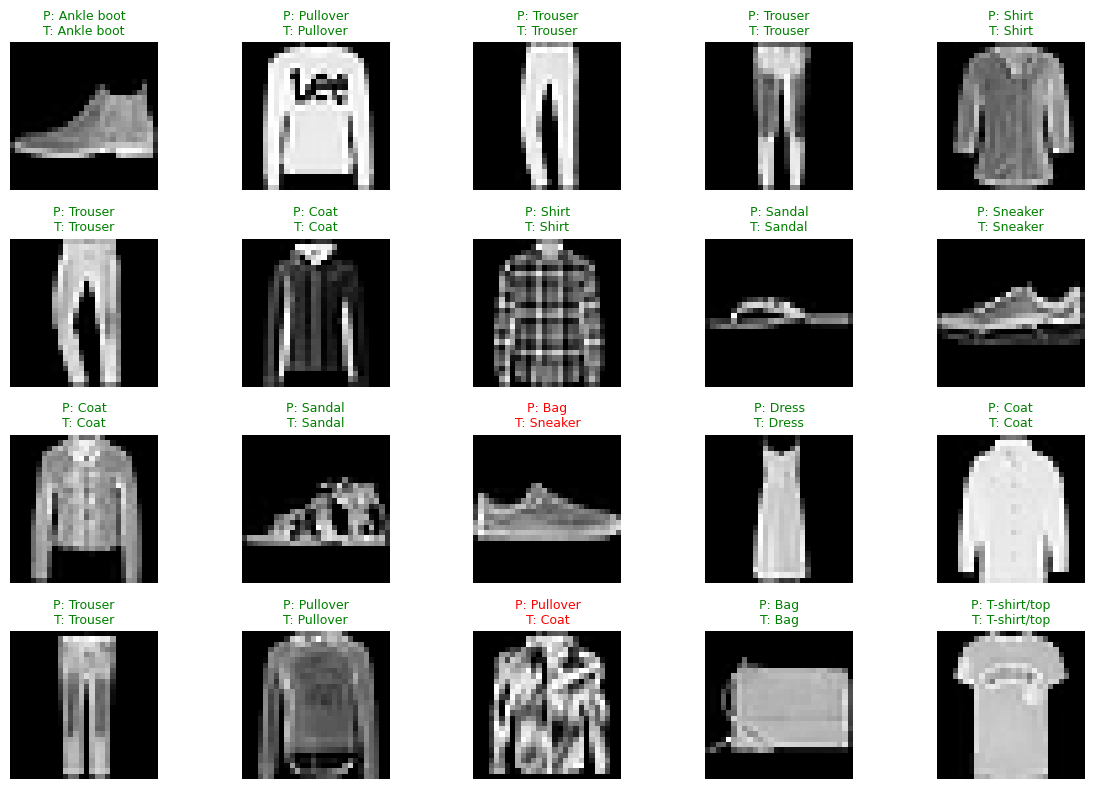

In [13]:
plt.figure(figsize=(12, 8))

for i in range(20):
    prediction = model.predict(X_test[i:i+1], verbose=0)
    predicted_label = np.argmax(prediction)
    true_label = y_test[i]

    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")

    color = "green" if predicted_label == true_label else "red"

    plt.title(
        f"P: {class_names[predicted_label]}\nT: {class_names[true_label]}",
        color=color,
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
model.save("fashion_mnist_ann_model.h5")

print("Đã lưu model thành công!")

Đã lưu model thành công!


In [15]:
loaded_model = keras.models.load_model("fashion_mnist_ann_model.h5")

loss, acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print("Loaded model accuracy:", acc)

Loaded model accuracy: 0.8855000138282776
